# UMAP DATA GENERATION

## Loading libraries and importing packages

In [10]:
import math
import datetime
import numpy as np               # Basic mathematics
import pandas as pd              # Dataframes library
import matplotlib.pyplot as plt  # Visualization library
import seaborn as sns
import umap  # pip install umap-learn

from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from matplotlib.patches import Circle

# Differential Privacy Primitives

In [11]:
class PrivacyAccountant:
    def __init__(self, epsilon_budget, delta_budget):
        self.epsilon_budget = epsilon_budget
        self.delta_budget = delta_budget
        self._spent_epsilon = 0.0
        self._spent_delta = 0.0
        self._history = []

    def spend(self, eps, delta=0.0, tag=""):
        new_eps = self._spent_epsilon + eps
        new_delta = self._spent_delta + delta
        if new_eps > self.epsilon_budget or new_delta > self.delta_budget:
            raise RuntimeError(
                f"Privacy budget exceeded! Tried ({eps:.4f}, {delta:.2e}); "
                f"already spent ({self._spent_epsilon:.4f}, {self._spent_delta:.2e}); "
                f"budget ({self.epsilon_budget}, {self.delta_budget})."
            )
        self._spent_epsilon = new_eps
        self._spent_delta = new_delta
        self._history.append((tag, eps, delta))

    @property
    def remaining_epsilon(self):
        return self.epsilon_budget - self._spent_epsilon

    @property
    def remaining_delta(self):
        return self.delta_budget - self._spent_delta

    def report(self):
        lines = [
            "Privacy Budget Report:",
            f"  Total budget  : eps={self.epsilon_budget}, delta={self.delta_budget}",
            f"  Spent         : eps={self._spent_epsilon:.4f}, delta={self._spent_delta:.2e}",
            f"  Remaining     : eps={self.remaining_epsilon:.4f}, delta={self.remaining_delta:.2e}",
            f"  Total releases: {len(self._history)}",
        ]
        return "\n".join(lines)


def gaussian_noise_sigma(l2_sensitivity, epsilon_dp, delta):
    if delta <= 0 or delta >= 1:
        raise ValueError("delta must be in (0, 1)")
    return l2_sensitivity * math.sqrt(2 * math.log(1.25 / delta)) / epsilon_dp


def apply_gaussian_noise(data, l2_sensitivity, epsilon_dp, delta, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    sigma = gaussian_noise_sigma(l2_sensitivity, epsilon_dp, delta)
    return data + rng.normal(0.0, sigma, size=data.shape)


def apply_laplace_noise(data, l1_sensitivity, epsilon_dp, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    scale = l1_sensitivity / epsilon_dp
    return data + rng.laplace(0.0, scale, size=data.shape)


# Sensitivity helpers (conservative assumptions for demonstration)
def umap_l2_sensitivity_per_axis(per_axis=1.0):
    return math.sqrt(2) * per_axis


def reliability_l1_sensitivity():
    return 0.8


# Centralised DP configuration used by every hospital
DEFAULT_DP_CONFIG = {
    "epsilon_dp": 1.0,                  # for L1 (UMAP coords) and L3 (output features)
    "epsilon_validation": 1.0,          # for L2 (reliability scores)
    "delta": 1e-5,
    "l1_sensitivity_reliability": 0.8,  # for L2
    "l2_sensitivity_umap": math.sqrt(2) * 1.0,  # for L1 (per-axis ~1.0)
    "l2_sensitivity_output": 1.0,       # for L3 (after min-max scaling)
    "tolerance": 0.15,                  # tolerance for noisy reliability check
    "epsilon_budget_per_hospital": 500.0,
    "delta_budget_per_hospital": 1e-3,
}

print("Differential Privacy primitives loaded.")

Differential Privacy primitives loaded.


# 1. Function definition

In [12]:
def mad_centroid(group):
    return np.median(group, axis=0)

In [13]:
def cluster_CentroidRadius_DensityPercent(X_umap, y, density_th, percent_th):
    classes = np.unique(y)
    umap_clusters = {value: X_umap[y == value] for value in classes}
    class_counts = {value: np.sum(y == value) for value in classes}

    centroids = {value: mad_centroid(umap_clusters[value]) for value in classes}

    distances_to_centroids = []
    for point, value in zip(X_umap, y):
        centroid = centroids[value]
        distance = np.linalg.norm(point - centroid)
        distances_to_centroids.append(distance)
    distances_to_centroids = np.array(distances_to_centroids)

    radius = {}
    for value in classes:
        percent = 0
        rad = 1
        density = float("inf")

        while not (percent >= percent_th and density <= density_th):
            rad_def = rad
            rad += 1
            cluster_indices = (y == value)
            cluster_distances = distances_to_centroids[cluster_indices]
            n_samples_rad = np.sum(cluster_distances <= rad)
            area = math.pi * rad ** 2
            density = n_samples_rad / area if area > 0 else float("inf")
            percent = n_samples_rad / class_counts[value] if class_counts[value] > 0 else 0.0
            if rad > 1000:
                break
        radius[value] = rad_def

    return centroids, radius


def custom_round(value):
    return round(value * 2) / 2


def compute_feature_epsilons(X_ref_array, umap_ref, n_neigh=10):
    nbrs = NearestNeighbors(n_neighbors=n_neigh, algorithm='auto').fit(umap_ref)
    distances, indices = nbrs.kneighbors(umap_ref)
    eps_list = []
    for feat_idx in range(X_ref_array.shape[1]):
        mean_neighbor_feature = np.mean(X_ref_array[indices, feat_idx], axis=1)
        sample_feature = X_ref_array[:, feat_idx]
        feature_dis = np.abs(mean_neighbor_feature - sample_feature)
        eps = round(np.mean(feature_dis))
        eps_list.append(max(eps, 1))
    return eps_list


def reliability_from_distance(feature_distances, eps):
    rel = np.where(
        feature_distances <= eps, 1.0,
        np.where(feature_distances <= 2 * eps, 0.9,
        np.where(feature_distances <= 3 * eps, 0.8,
        np.where(feature_distances <= 4 * eps, 0.7,
        np.where(feature_distances <= 5 * eps, 0.6,
        np.where(feature_distances <= 6 * eps, 0.5, 0.2)))))
    )
    return rel

### FEDERATED PARTICIPANTS -- with Differential Privacy :

In [14]:
class Hospital1ReferenceSite:
    def __init__(self, X_reference_df, y_reference,
                 density_th=4, percent_th=0.9, n_neigh=10,
                 random_state=23, dp_config=None):
        self.X_reference_df = X_reference_df.copy()
        self.y_reference = np.asarray(y_reference).flatten()
        self.density_th = density_th
        self.percent_th = percent_th
        self.n_neigh = n_neigh
        self.random_state = random_state

        # DP setup
        self.dp_config = dp_config or DEFAULT_DP_CONFIG
        self.accountant = PrivacyAccountant(
            epsilon_budget=self.dp_config["epsilon_budget_per_hospital"],
            delta_budget=self.dp_config["delta_budget_per_hospital"],
        )
        self.rng = np.random.default_rng(random_state)

        # Local training
        self.X_reference = self.X_reference_df.to_numpy()
        self.norm_pipe = make_pipeline(StandardScaler()).fit(self.X_reference)
        X_reference_norm = self.norm_pipe.transform(self.X_reference_df)

        self.manifold = umap.UMAP(random_state=self.random_state).fit(
            X_reference_norm, self.y_reference
        )
        self.umap_reference = self.manifold.transform(X_reference_norm)

        self.centroids_coord, self.cluster_radius = cluster_CentroidRadius_DensityPercent(
            self.umap_reference, self.y_reference,
            self.density_th, self.percent_th
        )

        self.nbrs = NearestNeighbors(
            n_neighbors=self.n_neigh, algorithm='auto'
        ).fit(self.umap_reference)

    def share_umap_model(self):
        return self.norm_pipe, self.manifold

    def validate_generated_coordinates(self, umap_gen, target_value,
                                       miss_feat_index, eps, sel_reliability):
        # STEP 1: cluster validation (no noise here)
        class_labels = list(self.centroids_coord.keys())
        centroid_matrix = np.array([self.centroids_coord[c] for c in class_labels])
        distances_to_centroids = np.array([
            np.linalg.norm(umap_gen - centroid, axis=1)
            for centroid in centroid_matrix
        ])
        closest_centroid_indices = np.argmin(distances_to_centroids, axis=0)

        cluster_vector = np.full(len(umap_gen), np.nan)
        for i, min_distance in enumerate(np.min(distances_to_centroids, axis=0)):
            centroid_pos = closest_centroid_indices[i]
            centroid_label = class_labels[centroid_pos]
            if min_distance < self.cluster_radius[centroid_label]:
                cluster_vector[i] = centroid_label

        non_validated_pos = np.isnan(cluster_vector)

        # STEP 2: feature reliability
        distances, indices = self.nbrs.kneighbors(umap_gen)
        mean_neighbor_feature = np.mean(
            self.X_reference[indices, miss_feat_index], axis=1
        )
        feature_distances = np.abs(mean_neighbor_feature - target_value)
        feature_reliabilities = reliability_from_distance(feature_distances, eps)
        feature_reliabilities[non_validated_pos] = np.nan

        # STEP 3: L2 - Laplace noise on the reliability scores (DP layer)
        noisy_reliabilities = feature_reliabilities.copy()
        valid_idx = ~np.isnan(feature_reliabilities)
        if np.any(valid_idx):
            noisy_reliabilities[valid_idx] = apply_laplace_noise(
                feature_reliabilities[valid_idx],
                l1_sensitivity=self.dp_config["l1_sensitivity_reliability"],
                epsilon_dp=self.dp_config["epsilon_validation"],
                rng=self.rng,
            )
            self.accountant.spend(
                eps=self.dp_config["epsilon_validation"],
                tag=f"L2_reliability_target_{target_value}"
            )

        # Valid mask uses a tolerance because the noisy reliability is continuous
        tol = self.dp_config["tolerance"]
        valid_mask = np.zeros(len(umap_gen), dtype=bool)
        valid_mask[valid_idx] = np.abs(
            noisy_reliabilities[valid_idx] - sel_reliability
        ) < tol

        return {
            "cluster_vector": cluster_vector,
            "feature_reliabilities": noisy_reliabilities,
            "valid_mask": valid_mask,
        }


class IncompleteSite:

    def __init__(self, incomplete_df, name="IncompleteSite",
                 dp_config=None, random_state=23):
        self.incomplete_df = incomplete_df.copy()
        self.name = name
        self.dp_config = dp_config or DEFAULT_DP_CONFIG
        self.accountant = PrivacyAccountant(
            epsilon_budget=self.dp_config["epsilon_budget_per_hospital"],
            delta_budget=self.dp_config["delta_budget_per_hospital"],
        )
        self.rng = np.random.default_rng(random_state)

    def generate_candidates_and_transform(self, norm_pipe, manifold,
                                          miss_feat, target_value):
        generated_data = self.incomplete_df.copy()
        generated_data.insert(0, miss_feat, target_value)
        X_gen_norm = norm_pipe.transform(generated_data)
        umap_gen = manifold.transform(X_gen_norm)

        # L1: Gaussian noise on UMAP coords before they leave the hospital
        umap_gen_noisy = apply_gaussian_noise(
            umap_gen,
            l2_sensitivity=self.dp_config["l2_sensitivity_umap"],
            epsilon_dp=self.dp_config["epsilon_dp"],
            delta=self.dp_config["delta"],
            rng=self.rng,
        )
        self.accountant.spend(
            eps=self.dp_config["epsilon_dp"],
            delta=self.dp_config["delta"],
            tag=f"L1_umap_target_{target_value}"
        )

        return generated_data, umap_gen_noisy


# Backward-compatible alias
class Hospital2IncompleteSite(IncompleteSite):
    pass

### FEDERATED SYNTHETIC GENERATION FUNCTION:

In [15]:
def synthetic_data_umap_federated_dp(
    hospital1, incomplete_hospitals,
    minmax, step, eps, miss_feat, miss_feat_index,
    sel_reliability=1.0,
    apply_l3=True,
    output_file="synthetic_data_federated_DP.xlsx"
):

    norm_pipe, manifold = hospital1.share_umap_model()
    min_value = minmax[0]
    max_value = minmax[1]

    all_synthetic = pd.DataFrame()

    for hospital in incomplete_hospitals:
        print(f"\n=== Processing {hospital.name} ===")
        hospital_synthetic = pd.DataFrame()

        for target_value in np.arange(min_value, max_value + step, step):
            now = datetime.datetime.now()
            print(f"  Target value: {target_value}  {now.time()}")

            # L1 happens inside generate_candidates_and_transform
            generated_data, umap_gen = hospital.generate_candidates_and_transform(
                norm_pipe=norm_pipe, manifold=manifold,
                miss_feat=miss_feat, target_value=target_value
            )

            # L2 happens inside validate_generated_coordinates
            validation_results = hospital1.validate_generated_coordinates(
                umap_gen=umap_gen, target_value=target_value,
                miss_feat_index=miss_feat_index,
                eps=eps, sel_reliability=sel_reliability
            )

            cluster_vector = validation_results["cluster_vector"]
            valid_mask = validation_results["valid_mask"]

            generated_data_cluster = generated_data.copy()
            generated_data_cluster["case_csPCa"] = cluster_vector

            synthetic_data_target_value = generated_data_cluster.loc[valid_mask].copy()
            hospital_synthetic = pd.concat(
                [hospital_synthetic, synthetic_data_target_value],
                ignore_index=True
            )

        if len(hospital_synthetic) > 0:
            hospital_synthetic["hospital"] = hospital.name

        print(f"  -> {len(hospital_synthetic)} validated synthetic samples from {hospital.name}")
        all_synthetic = pd.concat([all_synthetic, hospital_synthetic], ignore_index=True)

    # L3: Gaussian noise on continuous output features (single release)
    if apply_l3 and len(all_synthetic) > 0:
        feature_cols = ['patient_age', 'psa', 'prostate_volume']
        for col in feature_cols:
            if col in all_synthetic.columns:
                col_min = all_synthetic[col].min()
                col_max = all_synthetic[col].max()
                col_range = col_max - col_min
                if col_range > 0:
                    scaled = (all_synthetic[col].values - col_min) / col_range
                    noisy_scaled = apply_gaussian_noise(
                        scaled,
                        l2_sensitivity=hospital1.dp_config["l2_sensitivity_output"],
                        epsilon_dp=hospital1.dp_config["epsilon_dp"],
                        delta=hospital1.dp_config["delta"],
                        rng=hospital1.rng,
                    )
                    noisy_scaled = np.clip(noisy_scaled, 0, 1)
                    all_synthetic[col] = noisy_scaled * col_range + col_min

        hospital1.accountant.spend(
            eps=hospital1.dp_config["epsilon_dp"],
            delta=hospital1.dp_config["delta"],
            tag="L3_output_features"
        )

    all_synthetic.to_excel(output_file, index=False)
    print(f"\nTotal synthetic samples across all hospitals: {len(all_synthetic)}")
    return all_synthetic



### PLOT HELPERS:

In [16]:
def plot_reference_umap(umap_ref, y_ref, centroids_coord=None, cluster_radius=None,
                        title="Reference UMAP", save_path=None):
    plt.figure(figsize=(8, 6))
    classes = np.unique(y_ref)
    colors = ['darkgoldenrod', 'tomato', 'navy', 'skyblue', 'purple']

    for i, c in enumerate(classes):
        idx = y_ref == c
        plt.scatter(umap_ref[idx, 0], umap_ref[idx, 1],
                    c=colors[i % len(colors)], label=str(c), s=5)

    if centroids_coord is not None and cluster_radius is not None:
        for value, centroid in centroids_coord.items():
            plt.scatter(centroid[0], centroid[1], c='black', marker='x', s=100)
            circle = Circle(centroid, cluster_radius[value], color='grey', alpha=0.1)
            plt.gca().add_patch(circle)

    plt.legend(title="case_csPCa")
    plt.title(title)
    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()


def plot_synthetic_umap(synth_data, random_state=23,
                        title="Federated synthetic data", save_path=None):
    X_synth = synth_data.drop(["case_csPCa"], axis=1)
    y_synth = synth_data["case_csPCa"].values.flatten()

    norm_pipe = make_pipeline(StandardScaler()).fit(X_synth)
    X_synth_norm = norm_pipe.transform(X_synth)

    manifold = umap.UMAP(random_state=random_state).fit(X_synth_norm, y_synth)
    umap_synth = manifold.transform(X_synth_norm)

    plt.figure(figsize=(8, 6))
    classes = np.unique(y_synth[~pd.isna(y_synth)])
    colors = ['darkgoldenrod', 'tomato', 'navy', 'skyblue', 'purple']

    for i, c in enumerate(classes):
        idx = y_synth == c
        plt.scatter(umap_synth[idx, 0], umap_synth[idx, 1],
                    c=colors[i % len(colors)], label=str(c), s=5)

    plt.legend(title="case_csPCa")
    plt.title(title)
    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()

### MAIN PIPELINE:

Original features:
['patient_age', 'psad', 'psa', 'psad_computed', 'prostate_volume', 'case_csPCa']


/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


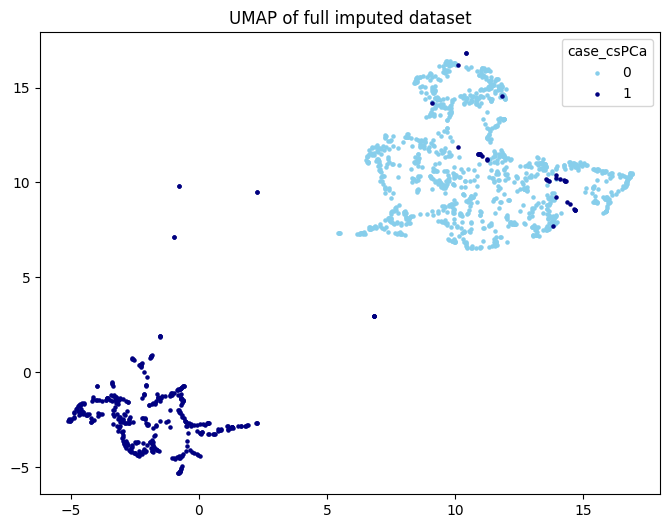

Shape of reference data (Hospital 1): (700, 4), Mean case_csPCa: 0.283
Shape of incomplete data (Hospital 2): (266, 4), Mean case_csPCa: 0.289
Shape of incomplete data (Hospital 3): (266, 4), Mean case_csPCa: 0.316
Shape of incomplete data (Hospital 4): (268, 4), Mean case_csPCa: 0.246


/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


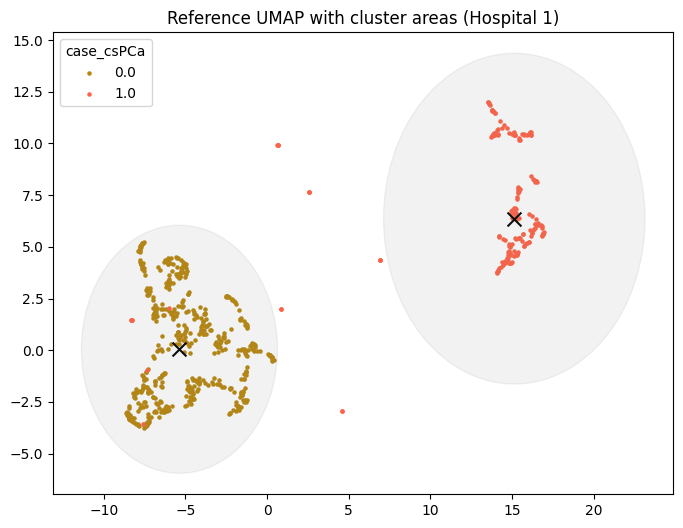

Epsilon for patient_age: 1
Epsilon for psa: 3
Epsilon for prostate_volume: 5

=== Processing Hospital 2 ===
  Target value: 35.0  23:47:31.047203


/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


  Target value: 36.0  23:47:31.287157


/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


  Target value: 37.0  23:47:31.529728


...

/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


  Target value: 87.0  23:48:09.552633


/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


  -> 410 validated synthetic samples from Hospital 4

Total synthetic samples across all hospitals: 1170

Final synthetic data shape: (1170, 5)
hospital
Hospital 2    382
Hospital 3    378
Hospital 4    410
Name: n_samples, dtype: int64
   patient_age         psa  prostate_volume  case_csPCa    hospital
0    35.000000    0.100000            252.0         0.0  Hospital 2
1    35.000000    0.100000            252.0         0.0  Hospital 2
2    87.000000    0.100000             13.0         0.0  Hospital 2
3    38.113678  129.396637             13.0         0.0  Hospital 2
4    35.000000  224.000000            252.0         0.0  Hospital 2


/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


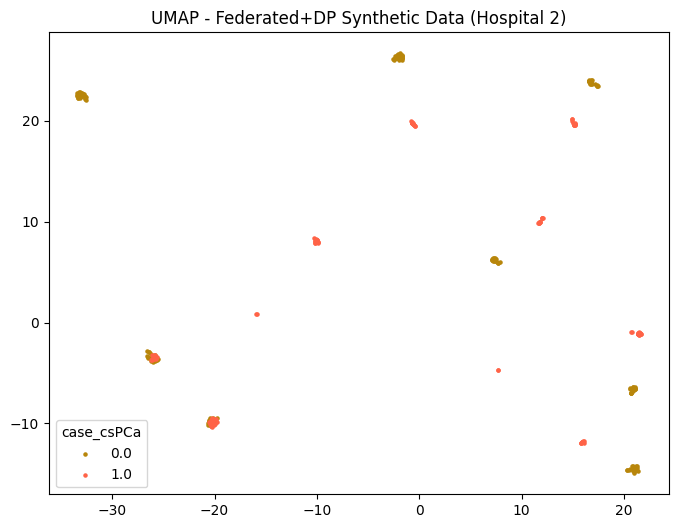

/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


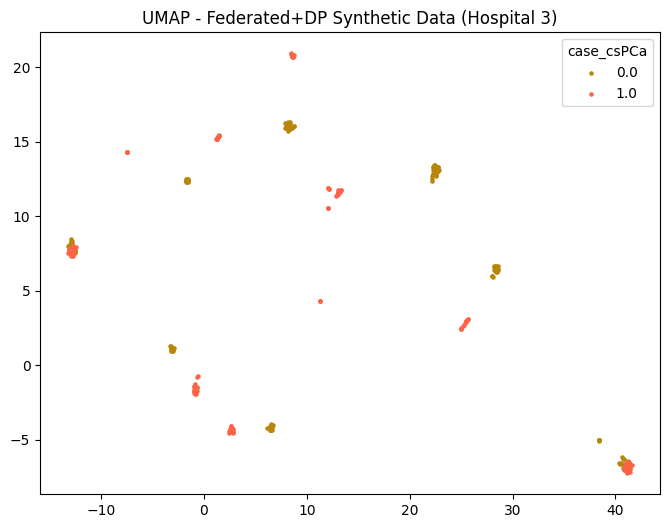

/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


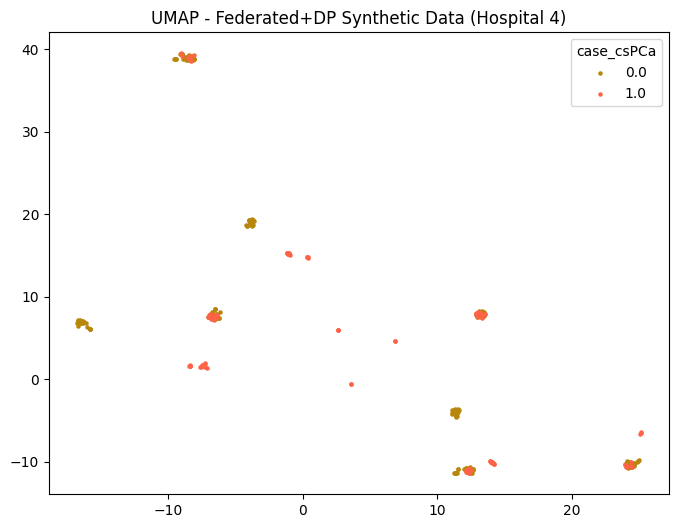

/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


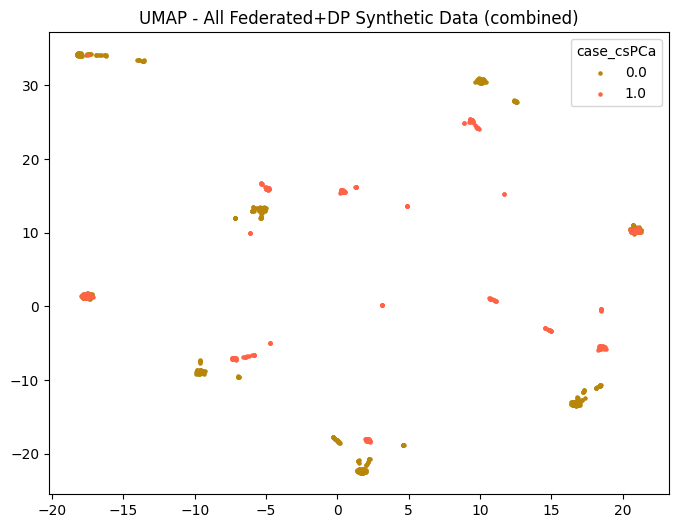


PRIVACY BUDGET REPORTS

--- Hospital1ReferenceSite (Hospital 1, reference) ---
Privacy Budget Report:
  Total budget  : eps=500.0, delta=0.001
  Spent         : eps=160.0000, delta=1.00e-05
  Remaining     : eps=340.0000, delta=9.90e-04
  Total releases: 160

--- Hospital 2 (incomplete) ---
Privacy Budget Report:
  Total budget  : eps=500.0, delta=0.001
  Spent         : eps=53.0000, delta=5.30e-04
  Remaining     : eps=447.0000, delta=4.70e-04
  Total releases: 53

--- Hospital 3 (incomplete) ---
Privacy Budget Report:
  Total budget  : eps=500.0, delta=0.001
  Spent         : eps=53.0000, delta=5.30e-04
  Remaining     : eps=447.0000, delta=4.70e-04
  Total releases: 53

--- Hospital 4 (incomplete) ---
Privacy Budget Report:
  Total budget  : eps=500.0, delta=0.001
  Spent         : eps=53.0000, delta=5.30e-04
  Remaining     : eps=447.0000, delta=4.70e-04
  Total releases: 53


In [17]:
if __name__ == "__main__":

    # Load data 
    picai = pd.read_csv("marksheet_minimal.csv")
    print("Original features:")
    print(list(picai.columns))

    picai_psa = picai.drop(["psad", "psad_computed"], axis=1)
    picai_col = picai_psa.columns

    # Impute missing values 
    knn_imputer = KNNImputer(n_neighbors=10)
    picai_psa_imputed = knn_imputer.fit_transform(picai_psa.copy())
    picai_psa_imputed = pd.DataFrame(picai_psa_imputed, columns=picai_col)

    # Full dataset UMAP (optional check) 
    random_state = 23
    X_picai = picai_psa_imputed.drop(["case_csPCa"], axis=1)
    y_picai = picai_psa_imputed["case_csPCa"].values.flatten()

    norm_pipe_full = make_pipeline(StandardScaler()).fit(X_picai)
    X_norm_full = norm_pipe_full.transform(X_picai.copy())
    manifold_full = umap.UMAP(random_state=random_state).fit(X_norm_full, y_picai)
    X_umap_full = manifold_full.transform(X_norm_full)

    plt.figure(figsize=(8, 6))
    class_0_idx = y_picai == 0.0
    class_1_idx = y_picai == 1.0
    plt.scatter(X_umap_full[class_0_idx, 0], X_umap_full[class_0_idx, 1],
                c='skyblue', label='0', s=5)
    plt.scatter(X_umap_full[class_1_idx, 0], X_umap_full[class_1_idx, 1],
                c='navy', label='1', s=5)
    plt.legend(title="case_csPCa")
    plt.title("UMAP of full imputed dataset")
    plt.savefig("A_dp_full_umap.png", dpi=200, bbox_inches='tight')
    plt.show()

    # Split into reference + N-1 incomplete hospitals 
    N_HOSPITALS = 4

    reference_df, remaining_df = train_test_split(
        picai_psa_imputed,
        test_size=N_HOSPITALS * 200,
        stratify=picai_psa_imputed["case_csPCa"],
        random_state=random_state + 5
    )

    print(f'Shape of reference data (Hospital 1): {reference_df.shape}, '
          f'Mean case_csPCa: {reference_df["case_csPCa"].mean():.3f}')

    incomplete_dfs = []
    split_remaining = remaining_df.copy().reset_index(drop=True)
    fold_size = len(split_remaining) // (N_HOSPITALS - 1)

    for i in range(N_HOSPITALS - 1):
        start = i * fold_size
        end = start + fold_size if i < N_HOSPITALS - 2 else len(split_remaining)
        incomplete_dfs.append(split_remaining.iloc[start:end].reset_index(drop=True))
        print(f'Shape of incomplete data (Hospital {i+2}): {incomplete_dfs[-1].shape}, '
              f'Mean case_csPCa: {incomplete_dfs[-1]["case_csPCa"].mean():.3f}')

    # Prepare reference and incomplete sets 
    X_ref_df = reference_df.drop(["case_csPCa"], axis=1)
    y_ref = reference_df["case_csPCa"].values.flatten()

    incomplete_X_dfs = [
        df.drop(["case_csPCa", "patient_age"], axis=1).copy()
        for df in incomplete_dfs
    ]

    # Hospital 1 local training (with DP accountant) 
    density_th = 4
    percent_th = 0.9
    n_neigh = 10

    hospital1 = Hospital1ReferenceSite(
        X_reference_df=X_ref_df, y_reference=y_ref,
        density_th=density_th, percent_th=percent_th,
        n_neigh=n_neigh, random_state=random_state,
        dp_config=DEFAULT_DP_CONFIG,
    )

    plot_reference_umap(
        hospital1.umap_reference, y_ref,
        centroids_coord=hospital1.centroids_coord,
        cluster_radius=hospital1.cluster_radius,
        title="Reference UMAP with cluster areas (Hospital 1)",
        save_path="A_dp_ref_umap.png"
    )

    # Define value ranges 
    X_ref = X_ref_df.to_numpy()
    psa_values = X_ref[:, 1]
    sorted_psa_values = np.sort(psa_values)
    rounded_values = np.array([custom_round(val) for val in sorted_psa_values])

    minmax_psa = [0, 100]
    step_psa = 0.5

    min_values = np.min(X_ref, axis=0)
    max_values = np.max(X_ref, axis=0)

    minmax_age = [min_values[0], max_values[0]]
    minmax_pvol = [min_values[2], max_values[2]]
    step_age = 1
    step_pvol = 1

    minmax_v = [minmax_age, minmax_psa, minmax_pvol]
    step_v = [step_age, step_psa, step_pvol]

    # Compute epsilons 
    eps_v = compute_feature_epsilons(
        X_ref_array=X_ref,
        umap_ref=hospital1.umap_reference,
        n_neigh=n_neigh
    )

    eps_age, eps_psa, eps_pvol = eps_v
    print("Epsilon for patient_age:", eps_age)
    print("Epsilon for psa:", eps_psa)
    print("Epsilon for prostate_volume:", eps_pvol)

    # Instantiate incomplete hospitals (each with its own DP accountant)
    incomplete_hospitals = [
        IncompleteSite(
            incomplete_df=X_df,
            name=f"Hospital {i+2}",
            dp_config=DEFAULT_DP_CONFIG,
            random_state=random_state + i,
        )
        for i, X_df in enumerate(incomplete_X_dfs)
    ]

    # Federated synthetic generation WITH DP 
    synth_data = synthetic_data_umap_federated_dp(
        hospital1=hospital1,
        incomplete_hospitals=incomplete_hospitals,
        minmax=minmax_age, step=step_age, eps=eps_age,
        miss_feat="patient_age", miss_feat_index=0,
        sel_reliability=1.0,
        apply_l3=True,
        output_file="synthetic_data_federated_DP.xlsx"
    )

    print("\nFinal synthetic data shape:", synth_data.shape)
    print(synth_data.groupby("hospital").size().rename("n_samples"))
    print(synth_data.head())

    # Visualise synthetic data per hospital 
    for hosp_name, group in synth_data.groupby("hospital"):
        group_no_hosp = group.drop(columns=["hospital"])
        if len(group_no_hosp) > 0:
            safe_name = hosp_name.replace(" ", "_")
            plot_synthetic_umap(
                synth_data=group_no_hosp,
                random_state=random_state,
                title=f"UMAP - Federated+DP Synthetic Data ({hosp_name})",
                save_path=f"A_dp_synth_{safe_name}.png"
            )
        else:
            print(f"No synthetic samples for {hosp_name}.")

    # Combined visualisation 
    if len(synth_data) > 0:
        plot_synthetic_umap(
            synth_data=synth_data.drop(columns=["hospital"]),
            random_state=random_state,
            title="UMAP - All Federated+DP Synthetic Data (combined)",
            save_path="A_dp_synth_combined.png"
        )

    # Privacy budget reports 
    print("\n" + "=" * 60)
    print("PRIVACY BUDGET REPORTS")
    print("=" * 60)
    print(f"\n--- {hospital1.__class__.__name__} (Hospital 1, reference) ---")
    print(hospital1.accountant.report())
    for hosp in incomplete_hospitals:
        print(f"\n--- {hosp.name} (incomplete) ---")
        print(hosp.accountant.report())


### Evaluation: Fidelity, Utility, Survival rate

In [18]:
from scipy.stats import ks_2samp
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score

# Fidelity: KS distance 
ks_results = {}
for feature in ['patient_age', 'psa', 'prostate_volume']:
    stat, _ = ks_2samp(picai_psa_imputed[feature], synth_data[feature])
    ks_results[feature] = stat

print('KS distance per feature:')
for f, v in ks_results.items():
    print(f'  {f}: {v:.4f}')
print(f'Mean KS distance: {sum(ks_results.values()) / len(ks_results):.4f}')

# Utility: TSTR with Random Forest 
X_real = picai_psa_imputed.drop('case_csPCa', axis=1)
y_real = picai_psa_imputed['case_csPCa']
_, X_test_real, _, y_test_real = train_test_split(
    X_real, y_real, test_size=0.3, stratify=y_real, random_state=42
)

X_synth = synth_data.drop(['case_csPCa', 'hospital'], axis=1)
y_synth = synth_data['case_csPCa']

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_synth, y_synth)
y_pred = clf.predict(X_test_real)
y_proba = clf.predict_proba(X_test_real)[:, 1]

print()
print(f'TSTR AUC:      {roc_auc_score(y_test_real, y_proba):.4f}')
print(f'TSTR F1:       {f1_score(y_test_real, y_pred):.4f}')
print(f'TSTR Accuracy: {accuracy_score(y_test_real, y_pred):.4f}')

# Summary
print()
print('Validated synthetic samples per hospital:')
print(synth_data.groupby('hospital').size().rename('n_samples'))
print(f'Total: {len(synth_data)}')

# Privacy budget summary 
print()
print("Privacy budget consumed:")
print(f"  Hospital 1 (reference): eps={hospital1.accountant._spent_epsilon:.4f}, "
      f"delta={hospital1.accountant._spent_delta:.2e}")
for hosp in incomplete_hospitals:
    print(f"  {hosp.name:30s}: eps={hosp.accountant._spent_epsilon:.4f}, "
          f"delta={hosp.accountant._spent_delta:.2e}")


KS distance per feature:
  patient_age: 0.4709
  psa: 0.5053
  prostate_volume: 0.4873
Mean KS distance: 0.4878

TSTR AUC:      0.5421
TSTR F1:       0.0714
TSTR Accuracy: 0.7111

Validated synthetic samples per hospital:
hospital
Hospital 2    382
Hospital 3    378
Hospital 4    410
Name: n_samples, dtype: int64
Total: 1170

Privacy budget consumed:
  Hospital 1 (reference): eps=160.0000, delta=1.00e-05
  Hospital 2                    : eps=53.0000, delta=5.30e-04
  Hospital 3                    : eps=53.0000, delta=5.30e-04
  Hospital 4                    : eps=53.0000, delta=5.30e-04
